Bài làm

In [2]:
# PHẦN 1 — Import thư viện
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications import MobileNetV3Small
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import numpy as np
import os
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

2025-10-25 12:10:25.474909: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1761394225.673998      37 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761394225.732971      37 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
# PHẦN 2 — Đường dẫn dữ liệu trên Kaggle
base_dir = '/kaggle/input/newplantv2/data'   # Thư mục gốc dữ liệu
train_dir = f"{base_dir}/train"              # Dữ liệu train
val_dir   = f"{base_dir}/valid"              # Dữ liệu validation


# PHẦN 3 — Tăng cường dữ liệu (Augmentation)
train_datagen = ImageDataGenerator(          
    preprocessing_function=preprocess_input, # Chuẩn hóa ảnh
    rotation_range=30,                       # Xoay ảnh
    width_shift_range=0.15,                  # Dịch ngang
    height_shift_range=0.15,                 # Dịch dọc
    shear_range=0.25,                        # Xiên ảnh
    zoom_range=0.2,                          # Phóng/thu nhỏ
    brightness_range=(0.8, 1.2),             # Độ sáng
    horizontal_flip=True,                    # Lật ngang
    vertical_flip=True,                      # Lật dọc
    fill_mode='nearest'                      # Điền điểm trống
)
val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input) # Validation


# PHẦN 4 — Tạo generator cho train và validation
train_gen = train_datagen.flow_from_directory(
    train_dir,                               # Thư mục train
    target_size=(224, 224),                  # Kích thước ảnh
    batch_size=16,                           # Số ảnh mỗi batch
    class_mode='categorical'                 # Dạng phân loại
)
val_gen = val_datagen.flow_from_directory(
    val_dir,                                 # Thư mục validation
    target_size=(224, 224),                  # Kích thước ảnh
    batch_size=16,                           # Số ảnh mỗi batch
    class_mode='categorical'                 # Dạng phân loại
)

Found 49630 images belonging to 38 classes.
Found 8269 images belonging to 38 classes.


In [4]:
# PHẦN 5 — Xây dựng mô hình MobileNetV3-Small
num_classes = len(train_gen.class_indices)    # Đếm số lớp (loại bệnh cây)

base_model = MobileNetV3Small(
    weights='imagenet',                       # Dùng trọng số pretrained trên ImageNet
    include_top=False,                        # Bỏ tầng phân loại gốc (1000 lớp)
    input_shape=(224, 224, 3)                 # Kích thước ảnh đầu vào
)

# Đóng băng các lớp của base_model
for layer in base_model.layers:
    layer.trainable = False                   # Giữ nguyên trọng số, không huấn luyện lại

# Xây phần head (phân loại mới)
model = Sequential([
    base_model,                               # Mạng nền trích xuất đặc trưng
    GlobalAveragePooling2D(),                 # Giảm chiều, tổng hợp đặc trưng
    Dropout(0.3),                             # Giảm overfitting
    Dense(128, activation='relu'),            # Lớp ẩn học đặc trưng mới
    Dropout(0.3),                             # Tiếp tục giảm overfitting
    Dense(num_classes, activation='softmax')  # Lớp đầu ra, dự đoán xác suất từng lớp
])

# Compile mô hình
model.compile(
    optimizer=Adam(learning_rate=1e-4),       # Bộ tối ưu Adam
    loss='categorical_crossentropy',          # Hàm mất mát cho phân loại đa lớp
    metrics=['accuracy']                      # Chỉ số đánh giá: độ chính xác
)

model.summary()                               # In tóm tắt kiến trúc mô hình

I0000 00:00:1761394253.312951      37 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ MobileNetV3Small (Functional)   │ (None, 7, 7, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,017,878 (3.88 MB)

 Trainable params: 78,758 (307.65 KB)

 Non-trainable params: 939,120 (3.58 MB)

In [5]:
# PHẦN 6 — Callbacks
early_stop = EarlyStopping(                   
    monitor='val_loss',                       # Theo dõi loss của validation
    patience=5,                               # Dừng nếu không cải thiện sau 5 epoch
    restore_best_weights=True                 # Khôi phục trọng số tốt nhất
)

reduce_lr = ReduceLROnPlateau(                
    monitor='val_loss',                       # Giảm learning rate khi val_loss không giảm
    factor=0.5,                               # Giảm một nửa LR
    patience=3,                               # Sau 3 epoch không cải thiện
    min_lr=1e-6                               # Giới hạn LR nhỏ nhất
)

checkpoint = ModelCheckpoint(                 
    '/kaggle/working/best_mobilenetv3small.keras',  # Nơi lưu mô hình tốt nhất
    monitor='val_accuracy',                   # Theo dõi độ chính xác validation
    save_best_only=True,                      # Chỉ lưu khi tốt hơn trước
    mode='max'                                # Chọn giá trị cao nhất (accuracy)
)

In [6]:
# PHẦN 7 — Fine-tune mô hình (train lại nhanh)
# Dùng MobileNetV3 pretrained, chỉ tinh chỉnh phần head

# Đóng băng phần lớn lớp (giữ nguyên trọng số)
for layer in model.layers[:-10]:
    layer.trainable = False                   # Không cập nhật trọng số

# Compile lại sau khi đổi trainable
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),  # Tốc độ học nhỏ
    loss='categorical_crossentropy',          # Mất mát đa lớp
    metrics=['accuracy']                      # Theo dõi độ chính xác
)

# Huấn luyện nhanh 3–5 epoch để tinh chỉnh
history = model.fit(
    train_gen,                                # Dữ liệu train
    validation_data=val_gen,                  # Dữ liệu val
    epochs=15,                                 # Số vòng lặp
    callbacks=[early_stop, reduce_lr, checkpoint]  # Gọi callback
)

Epoch 1/15


I0000 00:00:1761394275.492262     113 service.cc:148] XLA service 0x7c56580b8030 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1761394275.493055     113 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1761394276.754085     113 cuda_dnn.cc:529] Loaded cuDNN version 90300


   1/3102 ━━━━━━━━━━━━━━━━━━━━ 12:36:20 15s/step - accuracy: 0.0000e+00 - loss: 3.8399

I0000 00:00:1761394281.944099     113 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


3102/3102 ━━━━━━━━━━━━━━━━━━━━ 899s 285ms/step - accuracy: 0.1830 - loss: 3.0837 - val_accuracy: 0.7211 - val_loss: 1.1265 - learning_rate: 1.0000e-04
Epoch 2/15
3102/3102 ━━━━━━━━━━━━━━━━━━━━ 753s 243ms/step - accuracy: 0.5410 - loss: 1.5591 - val_accuracy: 0.7956 - val_loss: 0.7362 - learning_rate: 1.0000e-04
Epoch 3/15
3102/3102 ━━━━━━━━━━━━━━━━━━━━ 734s 237ms/step - accuracy: 0.6367 - loss: 1.1991 - val_accuracy: 0.8289 - val_loss: 0.6176 - learning_rate: 1.0000e-04
Epoch 4/15
3102/3102 ━━━━━━━━━━━━━━━━━━━━ 764s 246ms/step - accuracy: 0.6842 - loss: 1.0424 - val_accuracy: 0.8421 - val_loss: 0.5524 - learning_rate: 1.0000e-04
Epoch 5/15
3102/3102 ━━━━━━━━━━━━━━━━━━━━ 796s 257ms/step - accuracy: 0.7078 - loss: 0.9483 - val_accuracy: 0.8475 - val_loss: 0.5229 - learning_rate: 1.0000e-04
Epoch 6/15
3102/3102 ━━━━━━━━━━━━━━━━━━━━ 780s 251ms/step - accuracy: 0.7291 - loss: 0.8848 - val_accuracy: 0.8574 - val_loss: 0.4863 - learning_rate: 1.0000e-04
Epoch 7/15
3102/3102 ━━━━━━━━━━━━━━━━━━

In [7]:
# PHẦN 8 — Lưu mô hình cuối cùng
model.save('/kaggle/working/plant_disease_mobilenetv3small.keras')

Found 8269 images belonging to 38 classes.
517/517 ━━━━━━━━━━━━━━━━━━━━ 33s 55ms/step


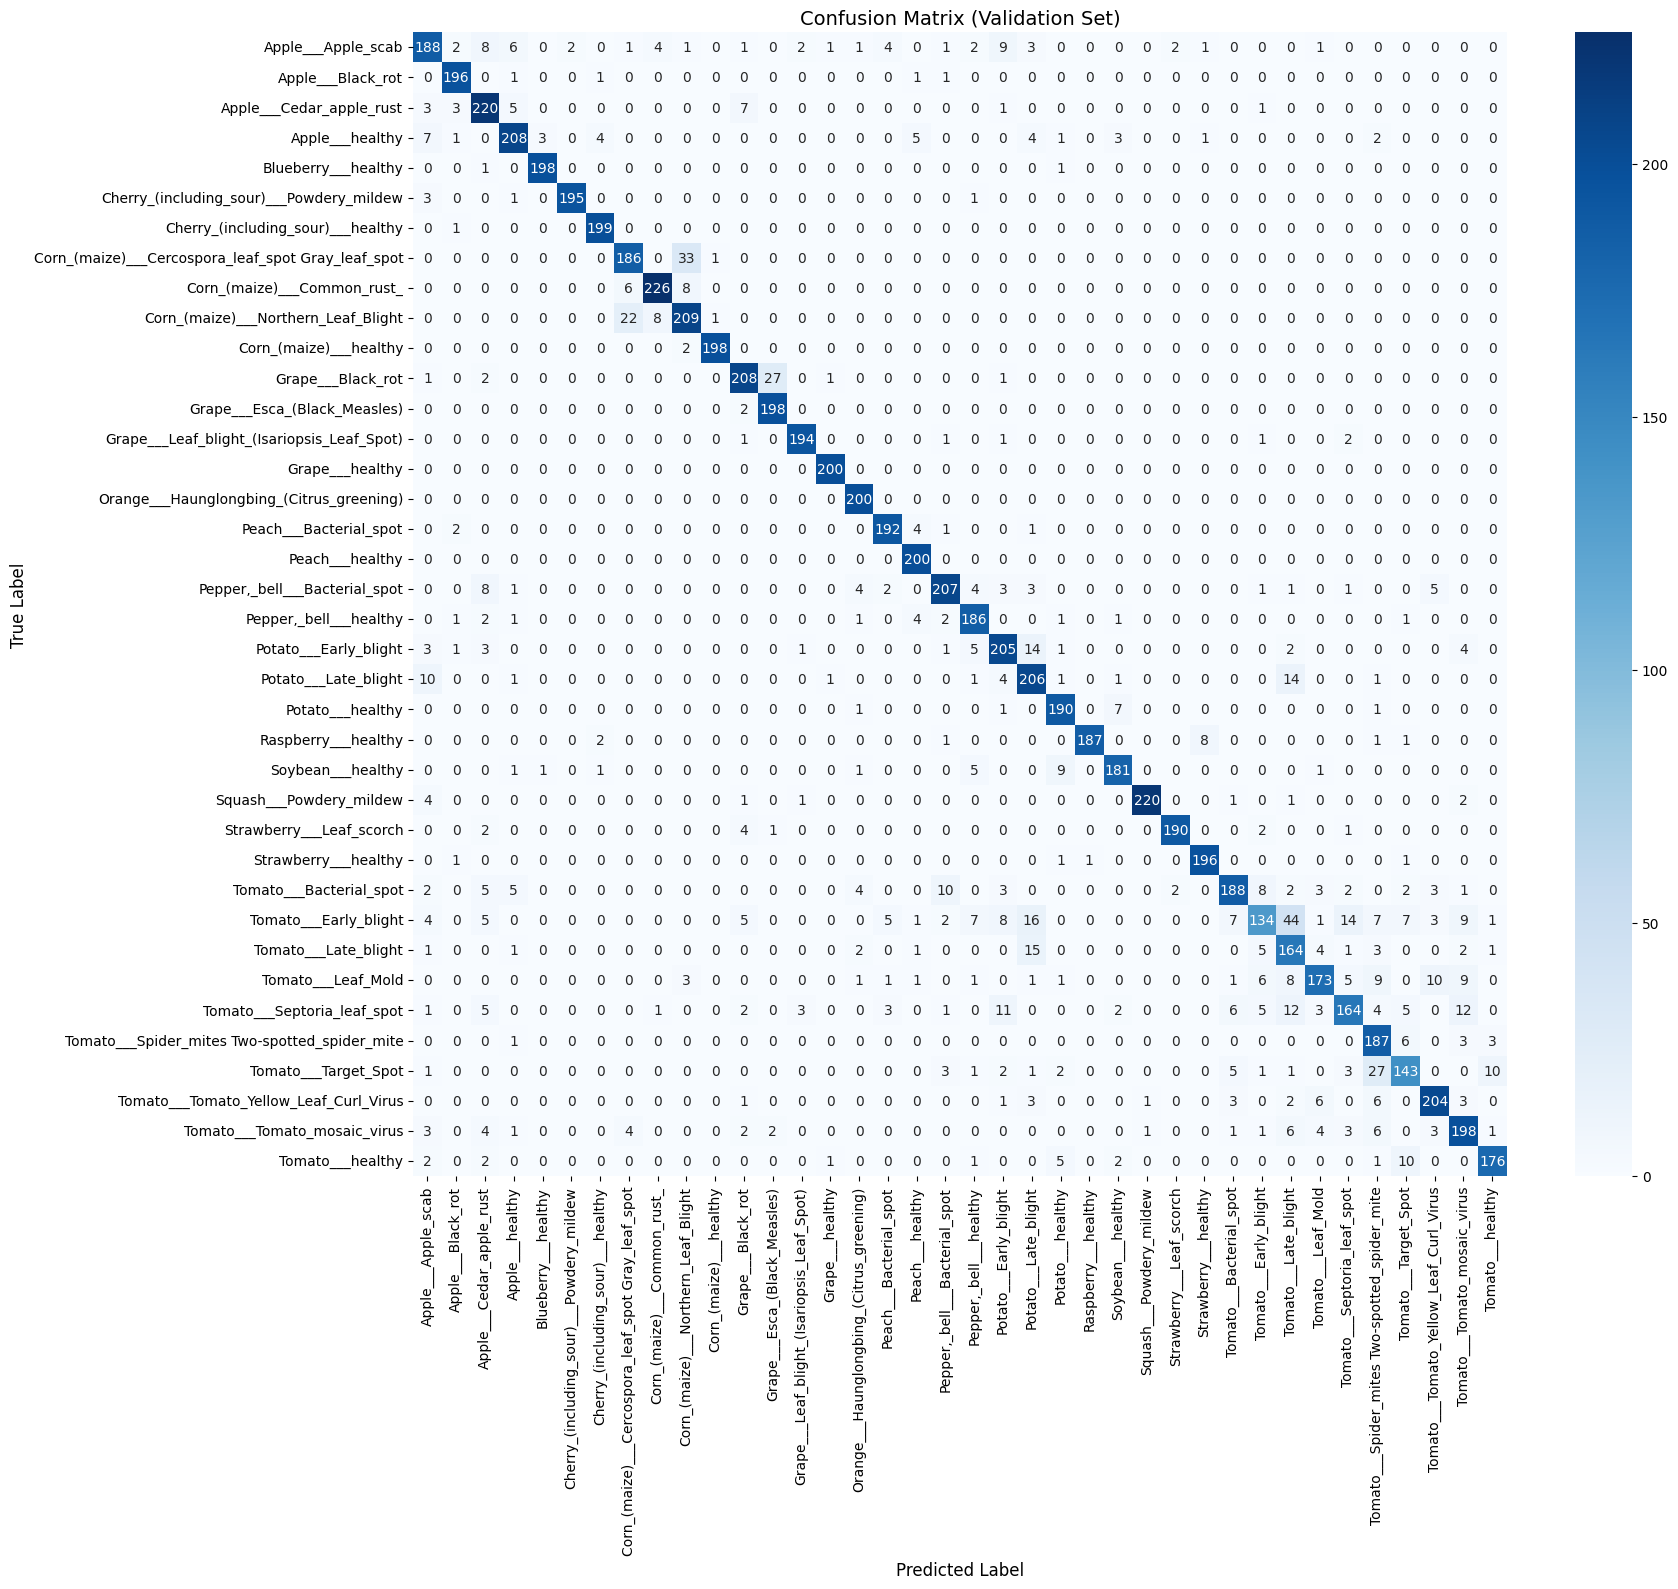


=== Classification Report ===

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.81      0.78      0.79       240
                                 Apple___Black_rot       0.94      0.98      0.96       200
                          Apple___Cedar_apple_rust       0.82      0.92      0.87       240
                                   Apple___healthy       0.89      0.87      0.88       239
                               Blueberry___healthy       0.98      0.99      0.99       200
          Cherry_(including_sour)___Powdery_mildew       0.99      0.97      0.98       200
                 Cherry_(including_sour)___healthy       0.96      0.99      0.98       200
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.85      0.85      0.85       220
                       Corn_(maize)___Common_rust_       0.95      0.94      0.94       240
               Corn_(maize)___Northern_Leaf_Bli

In [8]:
# PHẦN 9 — Ma trận và Báo cáo kết quả (sử dụng định dạng .keras an toàn)

import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Load model tốt nhất (định dạng .keras)
model = tf.keras.models.load_model('/kaggle/working/best_mobilenetv3small.keras')

# 2. Tạo generator validation (không shuffle)
val_gen_noshuffle = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical',
    shuffle=False
)

# 3. Dự đoán trên tập validation
pred_probs = model.predict(val_gen_noshuffle, verbose=1)
pred_classes = np.argmax(pred_probs, axis=1)
true_classes = val_gen_noshuffle.classes
class_labels = list(val_gen_noshuffle.class_indices.keys())

# 4. Ma trận nhầm lẫn
cm = confusion_matrix(true_classes, pred_classes)
plt.figure(figsize=(18, 16))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title("Confusion Matrix (Validation Set)", fontsize=14)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 5. Báo cáo phân loại chi tiết
print("\n=== Classification Report ===\n")
report = classification_report(true_classes, pred_classes, target_names=class_labels)
print(report)

# 6. Độ chính xác tổng thể
acc = np.mean(pred_classes == true_classes)
print(f"\n✅ Validation Accuracy: {acc:.4f}")

# 7. Lưu báo cáo ra file txt
with open("/kaggle/working/mobilenetv3small_report.txt", "w") as f:
    f.write(report)

print("\n✅ Đã lưu báo cáo tại: /kaggle/working/mobilenetv3small_report.txt")